# **06. Model Baseline**

### **Introduction**

In this study, various baseline machine learning algorithms are applied to the Bank Telemarketing dataset to perform binary classification. The objective is to compare the performance of these models using standard evaluation metrics and identify the algorithm that provides the most accurate and reliable predictions for customer subscription outcomes.

## **1. Data Loading**

In [1]:
# Import Libraries

import pandas as pd 
import numpy as np  
import sidetable
import sklearn
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from glob import glob
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from itertools import combinations


In [2]:
# Display Settings

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display
from IPython.display import Markdown

# Display markdown formatted output like bold, italic bold etc.'''
def display_md(string):
    display(Markdown(string))
    


In [6]:
# Load data

parent_path = Path.cwd().parent
path_data = parent_path.joinpath('data','processed')
files = []
for file in path_data.glob('*'):
    files.append(file)
    print(file.name)
    print(files.index(file), " ", file, end="\n\n")
 

.gitkeep
0   e:\Bank-Telemarketing\data\processed\.gitkeep

clean_data.csv
1   e:\Bank-Telemarketing\data\processed\clean_data.csv

funnel_data.csv
2   e:\Bank-Telemarketing\data\processed\funnel_data.csv



In [8]:
# Loading clean file
display_md("**Loading Clean-Funnel Dataset....**")
try:
    data = pd.read_csv(files[2])
    display(data.head(2))
    display_md(f"**Dataset Shape :** {data.shape}")
except Exception as e:
    print(f"Data Loading Error : {e}")


**Loading Clean-Funnel Dataset....**

,age,age_basket,job,marital,education,balance,balance_basket,default,housing,loan,contact,day,month,duration,duration_mins,duration_bucket,campaign,campaign_capped,pdays,previous,poutcome,term_deposit,term_deposit_numeric
0,58,50-66,management,married,tertiary,2143,High (2K+),no,yes,no,unknown,5,may,261,4.35,3-5 mins,1,1,-1,0,unknown,no,0
1,44,35-49,technician,single,secondary,29,Low (0-500),no,yes,no,unknown,5,may,151,2.52,1-3 mins,1,1,-1,0,unknown,no,0


**Dataset Shape :** (45211, 23)

# **2. Binary Classification Model Selection**

### **2.1. Handling Outliers**

In [10]:
# Lets create a copy of raw_df
df = data.copy(deep = True)

# since duration = 0 doesn't have predictive power, we can drop it
new_df = df.query('duration > 0').reset_index(drop=True)

new_df.shape

(45208, 23)

In [11]:
# plot outliers for numeric columns
def inspect_outliers(df:pd.DataFrame):
    # store numeric columns 
    numeric_col = df.select_dtypes(include=['number']).columns
    # iterate through each numeric column
    for col in numeric_col:
        fig, ax = plt.subplots(ncols=2, figsize=(15, 5))
        sns.boxplot(data=df, x = col, ax=ax[0], fill=False, color='k', flierprops=dict(marker='o', markerfacecolor='r'))
        sns.histplot(data=df, x = col, ax=ax[1], kde=False, color='lightblue')
        plt.suptitle(f'Outliers Analysis for {col.capitalize()}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

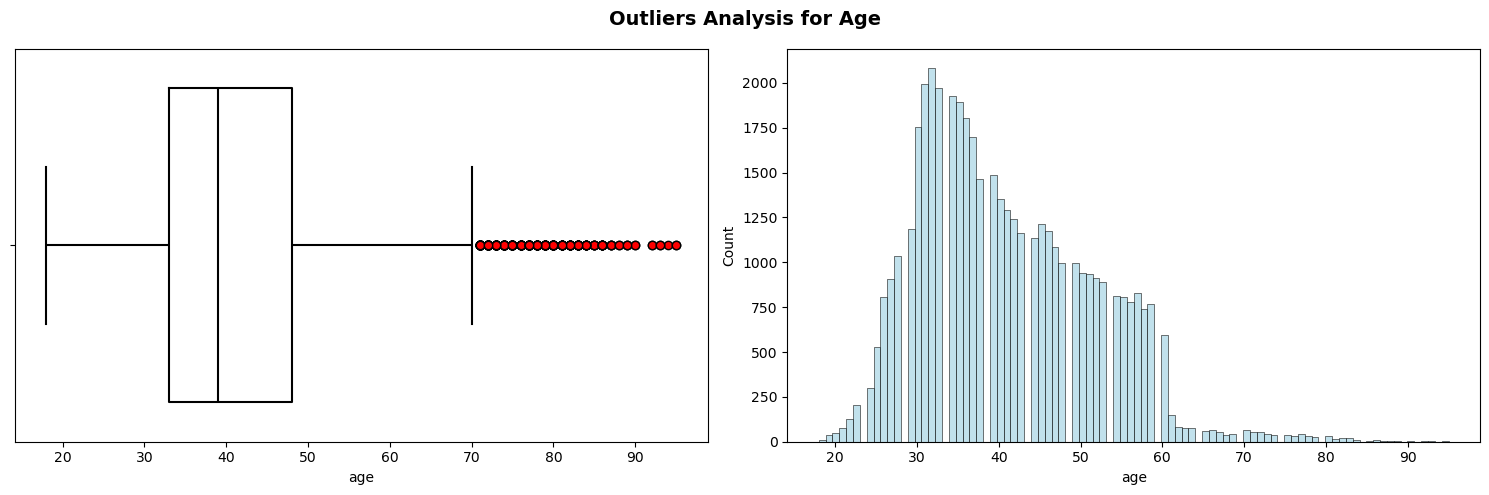

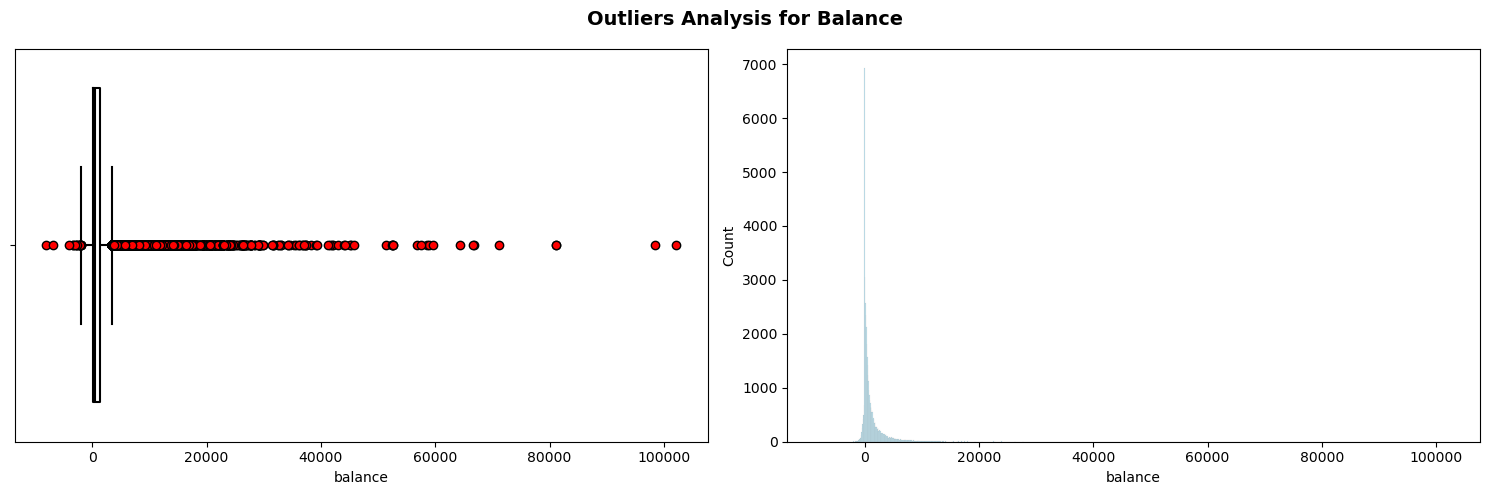

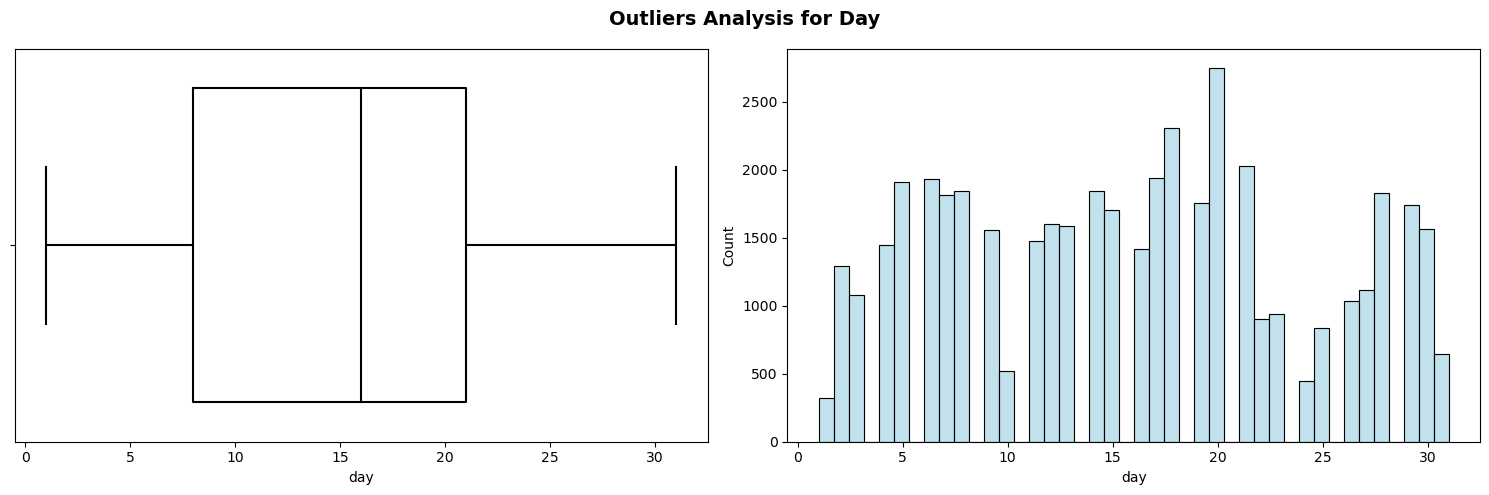

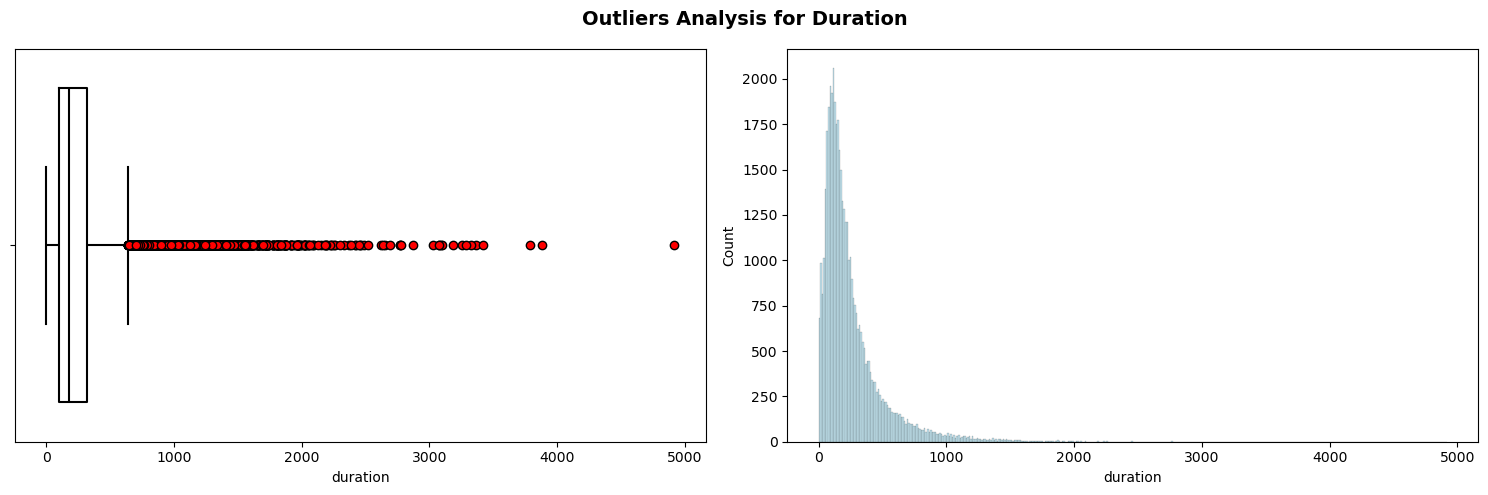

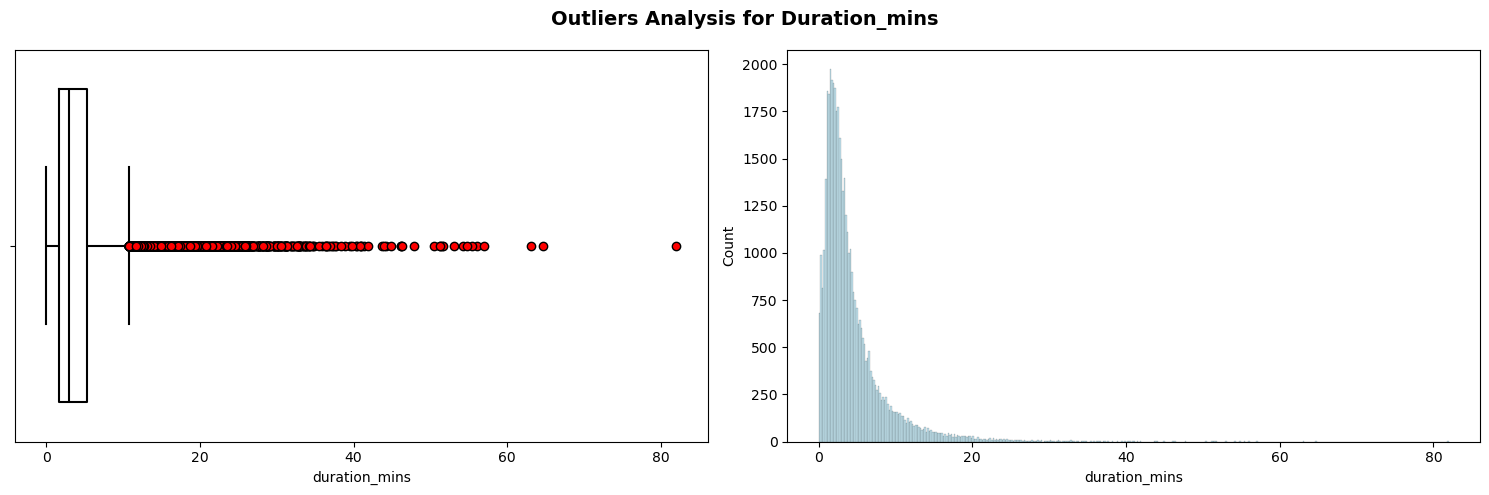

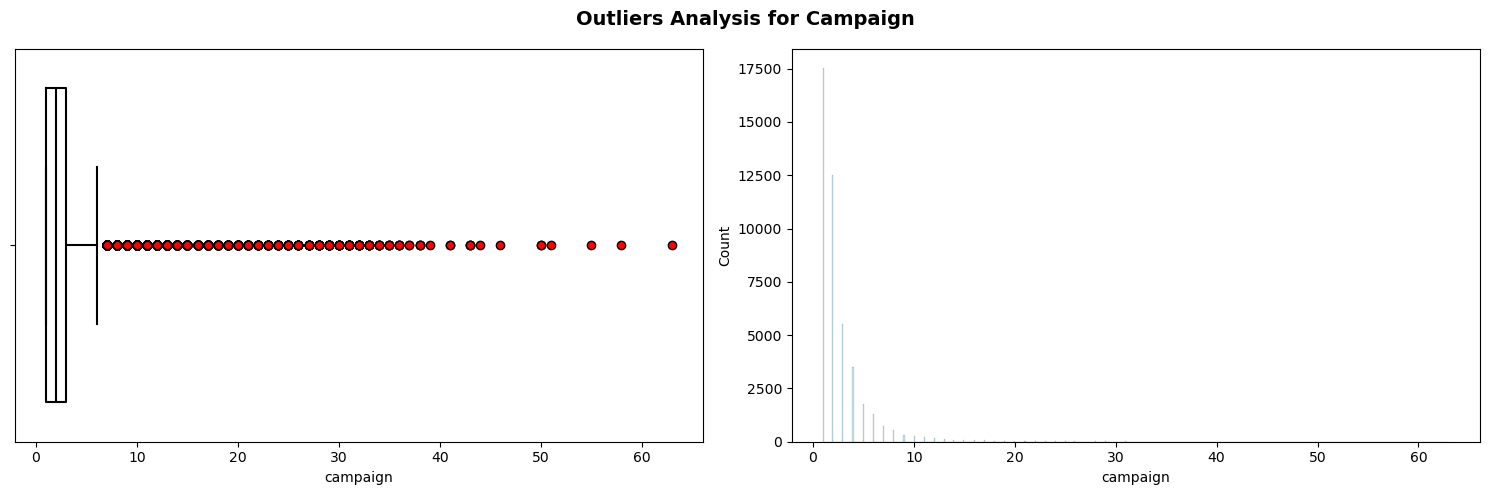

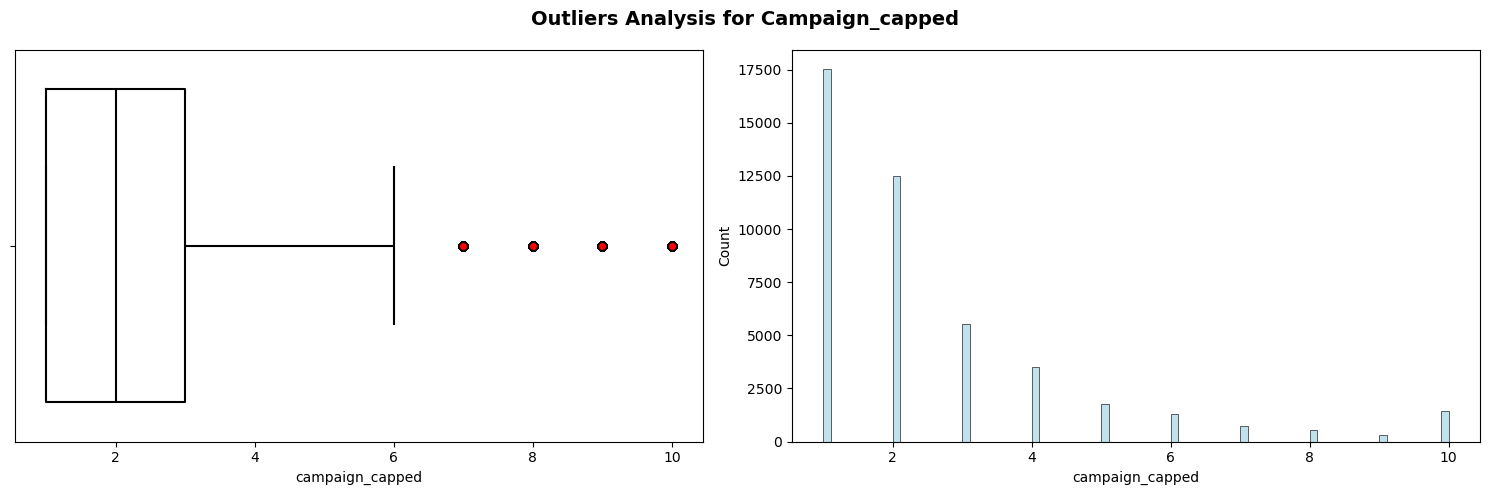

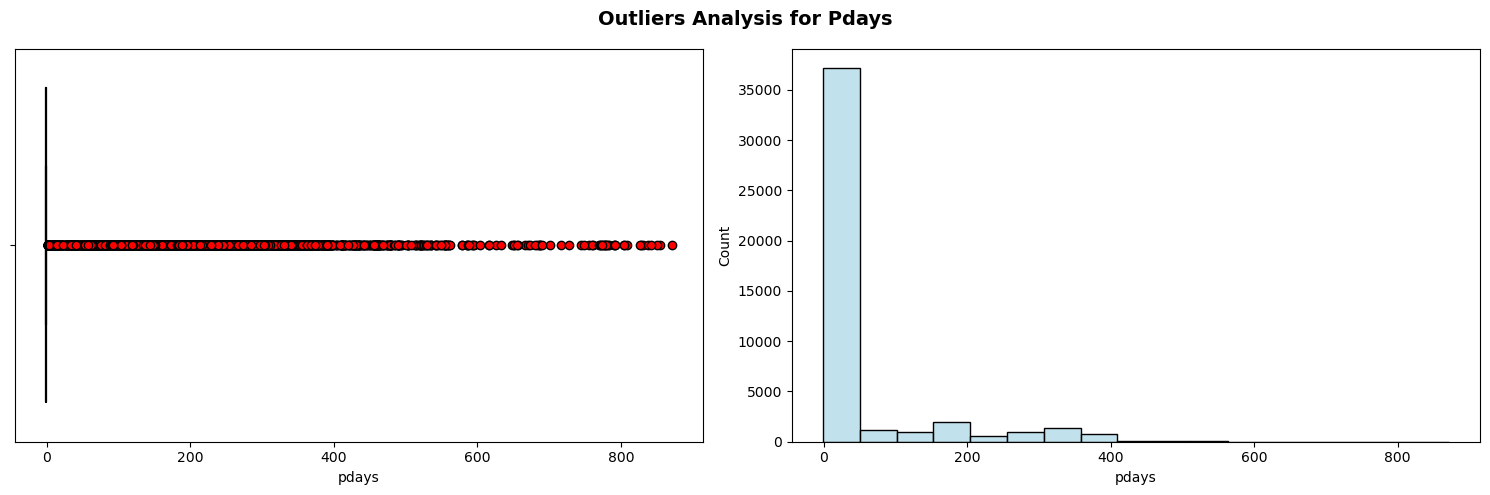

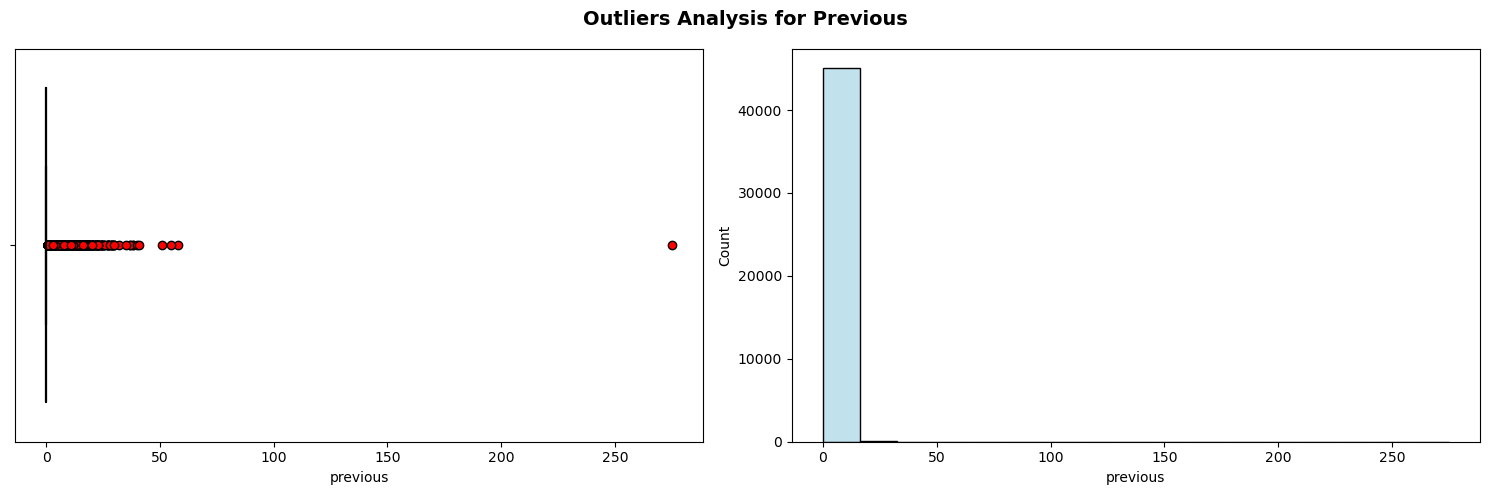

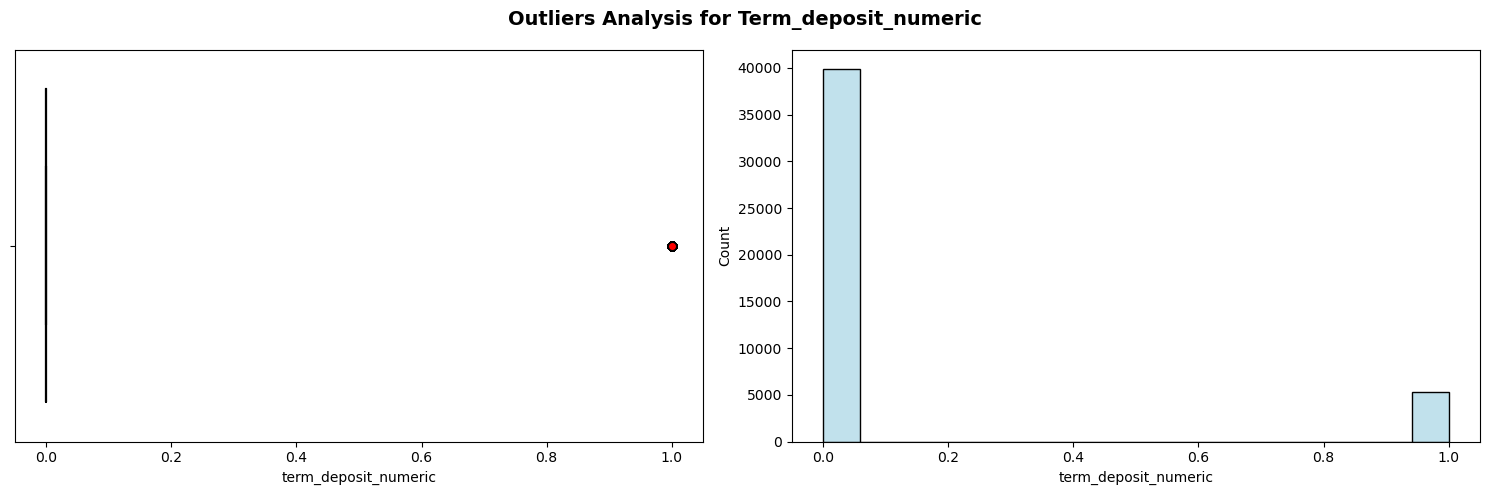

In [12]:
inspect_outliers(new_df)

In [19]:
# outliers percentage in each features
def calculate_outlier_percentage(df:pd.DataFrame, lower_percentile:float=5, upper_percentile: float=95) -> pd.DataFrame:
    """
    Calculate the percentage of outliers based on winsorized method for all the numeric columns in the DataFrame.

    Parameters:
    df(pd.DataFrame): The input DataFrame containing numerical features.
    lower_percentile(float): The lower percentile foe winsorization. Default is 5.
    upper_percentile(float): The upper percentile for winsorization. Default is 95.


    Returns:
    pd.DataFrame: A DataFrame contains features name along w.r.t their outlier percentage in it.
    """
    num_col = new_df.select_dtypes(include='number').columns.difference(['term_deposit_numeric'])
    variable = []
    outlier = []

    for col in num_col:
        x_low, x_high = np.percentile(new_df[col], [lower_percentile, upper_percentile])
        total = len(new_df[col])
        outliers_len = len(df[~df[col].between(x_low, x_high)])
        outlier_percentage = round((outliers_len/total)*100, 2)
        variable.append(col)
        outlier.append(outlier_percentage)

    outlier_df = pd.DataFrame(zip(variable, outlier), columns=['Features', 'Outliers Percentage'])
    return outlier_df

# Execute with given dataframe
anamoly_df = calculate_outlier_percentage(new_df, lower_percentile=1, upper_percentile=99)
anamoly_df.sort_values(by=['Outliers Percentage'],ascending=False).reset_index(drop=True)


,Features,Outliers Percentage
0,balance,2.00
1,duration,1.92
2,duration_mins,1.92
3,age,1.63
4,campaign,1.00
5,previous,1.00
6,pdays,0.85
7,day,0.71
8,campaign_capped,0.00


In [22]:
# Outlier Treatment using winsorization method 
def outlier_by_wisorize(df: pd.DataFrame, lower_percent:float=5, upper_percent:float=95, exclude_col:list=None)->pd.DataFrame:
    """
    A DataFrame with numeric columns in it.
    
    Parameters:
    df: the input DataFrame
    lower_percent: float value which by default take 5.
    upper_percent: float value which by default take 95.

    Return:
    A DataFrame without outliers.
    """
    df_winsorize = df.copy()
    num_col = df.select_dtypes(include='number').columns.difference(['term_deposit_numeric'])
    winsorize_col = set(num_col) - set(exclude_col) if exclude_col else num_col
    
    for col in winsorize_col:
        x_low, x_high = np.percentile(df[col],[lower_percent, upper_percent])
        df_winsorize[col] = np.where(df_winsorize[col] < x_low, x_low, df_winsorize[col]) # lower capping
        df_winsorize[col] = np.where(df_winsorize[col] > x_high, x_high, df_winsorize[col]) # upper capping

    return df_winsorize

winsorize_df = outlier_by_wisorize(new_df, lower_percent=1, upper_percent=99, exclude_col=['pdays'])


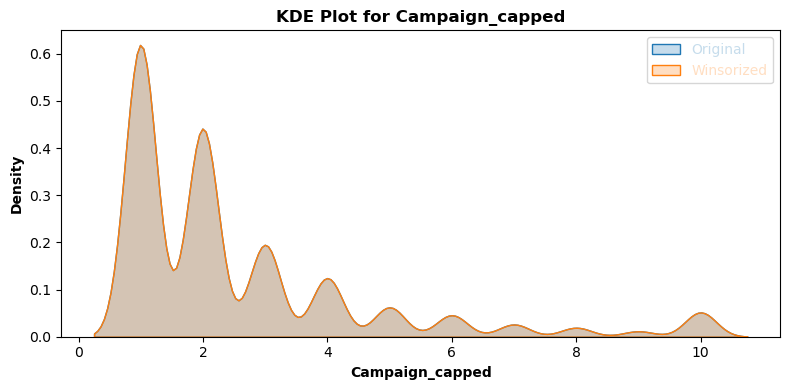

Wilcoxon rank-sum test for 'campaign_capped' : U Statistic: 1021881632.0000, P-Value: 1.0000
The Distributions of 'campaign_capped' are not statistically different (p_value > 0.05).


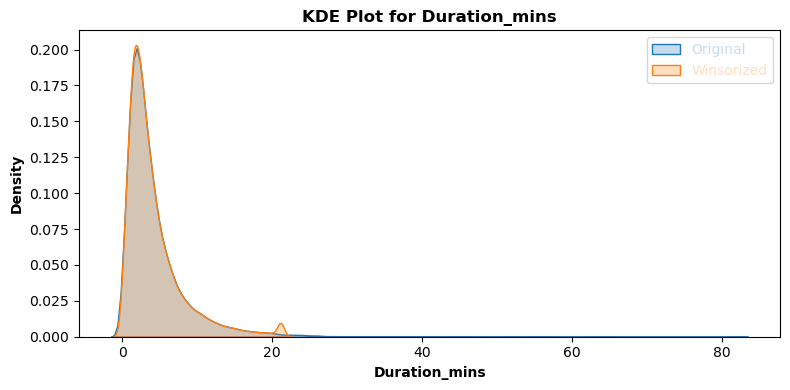

Wilcoxon rank-sum test for 'duration_mins' : U Statistic: 1021877996.0000, P-Value: 0.9993
The Distributions of 'duration_mins' are not statistically different (p_value > 0.05).


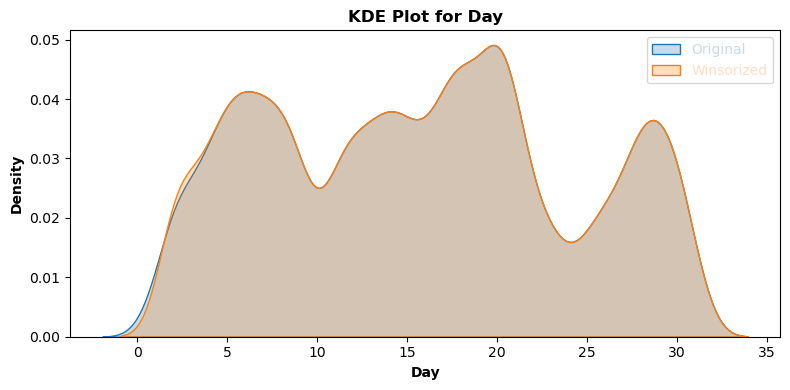

Wilcoxon rank-sum test for 'day' : U Statistic: 1021621617.0000, P-Value: 0.9471
The Distributions of 'day' are not statistically different (p_value > 0.05).


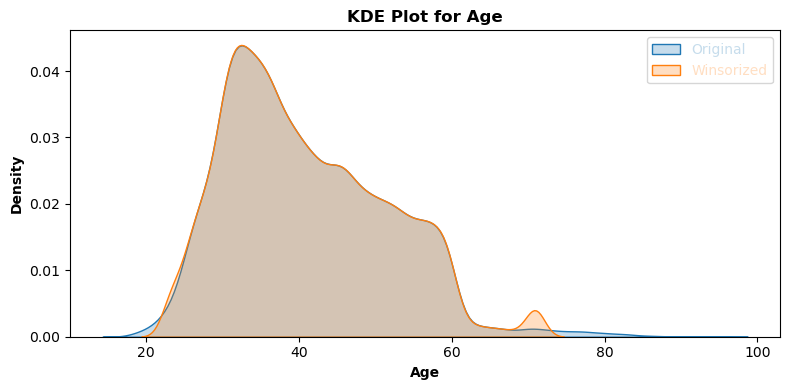

Wilcoxon rank-sum test for 'age' : U Statistic: 1021909750.0000, P-Value: 0.9943
The Distributions of 'age' are not statistically different (p_value > 0.05).


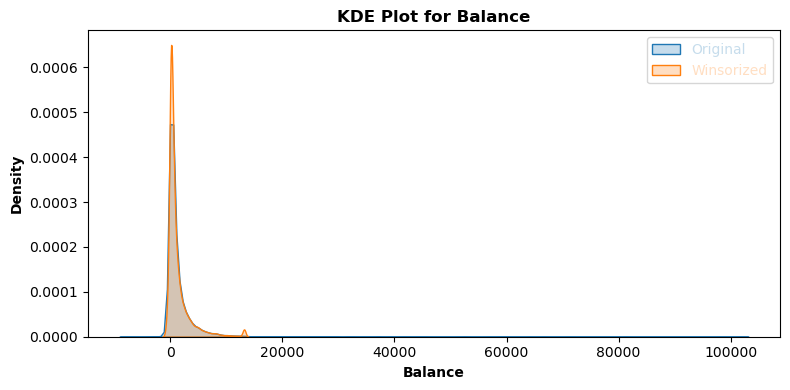

Wilcoxon rank-sum test for 'balance' : U Statistic: 1021882086.5000, P-Value: 0.9999
The Distributions of 'balance' are not statistically different (p_value > 0.05).


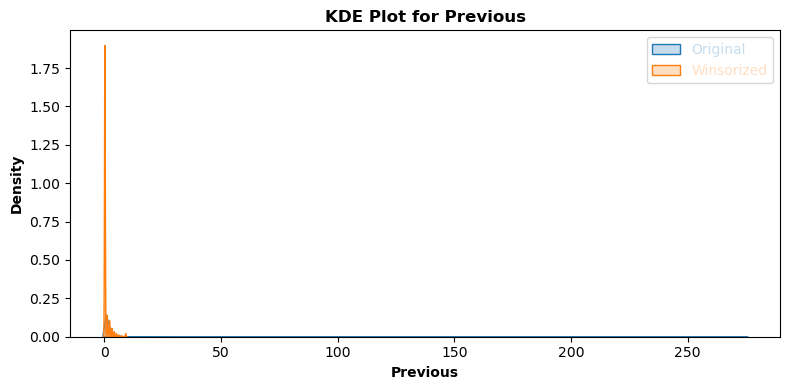

Wilcoxon rank-sum test for 'previous' : U Statistic: 1021984236.5000, P-Value: 0.9690
The Distributions of 'previous' are not statistically different (p_value > 0.05).


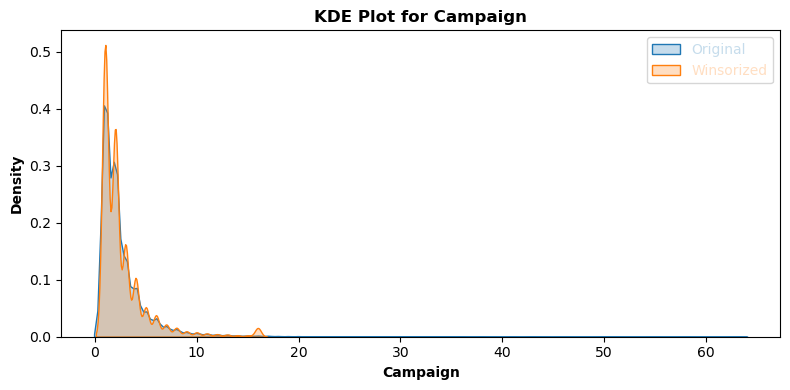

Wilcoxon rank-sum test for 'campaign' : U Statistic: 1022001147.0000, P-Value: 0.9746
The Distributions of 'campaign' are not statistically different (p_value > 0.05).


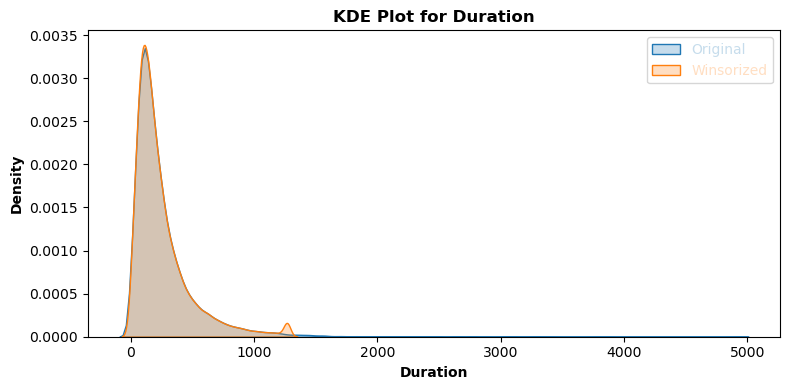

Wilcoxon rank-sum test for 'duration' : U Statistic: 1021877996.0000, P-Value: 0.9993
The Distributions of 'duration' are not statistically different (p_value > 0.05).


In [23]:
# check statistical difference or not of outlier capping on numeric columns
def plot_kde_before_after(df:pd.DataFrame, winsorize_df:pd.DataFrame, exclude_col:list):
    """
    Plot KDE for all numeric columns before and after winsorization and calculate wilcoxon rank-sum test results.

    Parameters:
    df: pd.DataFrame the original dataframe
    winsorize_df: winsorize method dataframe
    exclude_col: List of column to exclude from plotting
    """
    num_col = df.select_dtypes(include='number').columns.difference(['term_deposit_numeric'])
    plot_col = set(num_col) - set(exclude_col) if exclude_col else num_col

    #plot kdeplot
    for col in plot_col:
        fig, ax = plt.subplots(1,1, figsize=(8,4))
        sns.kdeplot(df[col], ax=ax, label='Original', fill=True)
        sns.kdeplot(winsorize_df[col], ax=ax, label='Winsorized', fill=True)
        plt.title(f"KDE Plot for {col.capitalize()}", fontweight='bold')
        plt.xlabel(f"{col.capitalize()}", fontweight='bold')
        plt.ylabel('Density', fontweight='bold')
        plt.legend(labelcolor='linecolor')

        plt.tight_layout()
        plt.show()
        # Wilcoxon rank-sum test
        u_stats, p_value = stats.mannwhitneyu(df[col], winsorize_df[col])
        print(f"Wilcoxon rank-sum test for '{col}' : U Statistic: {u_stats:.4f}, P-Value: {p_value:.4f}")
        if p_value < 0.05:
            print(f"The Distributions of '{col}' are statistically different (p_value < 0.05).")
        else:
            print(f"The Distributions of '{col}' are not statistically different (p_value > 0.05).")

# Applying function to dataframe
plot_kde_before_after(new_df, winsorize_df, exclude_col=['pdays']) 



### **2.2. Feature Importance and Correlation**

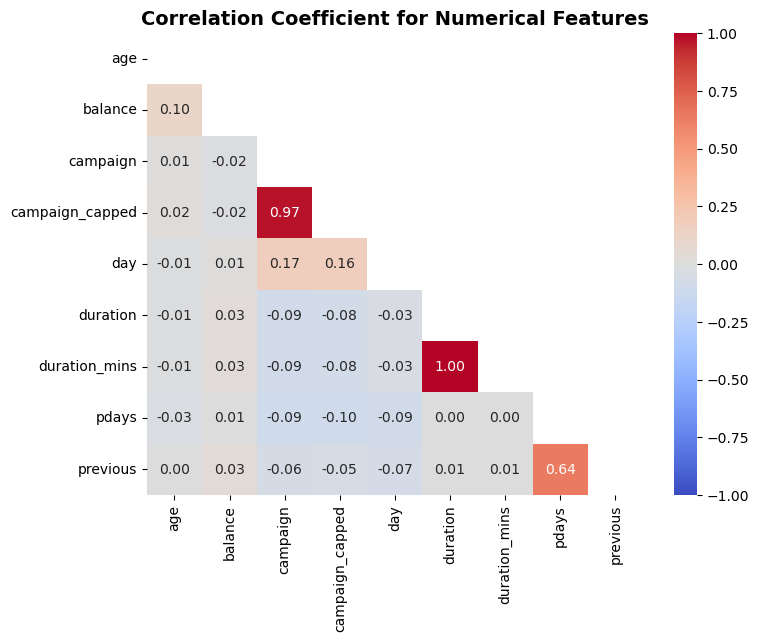

In [ ]:
# Calculate correlation of numerical columns
corr_df = winsorize_df[winsorize_df.select_dtypes(include='number').columns.difference(['term_deposit_numeric']).tolist()].corr()

# Generate a mask for upper triangle
mask = np.zeros_like(corr_df, dtype=bool)
mask[np.triu_indices_from(mask)] = True
# plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_df, annot=True, fmt='.2f', mask=mask, cmap='coolwarm',vmin=-1, vmax=1, cbar=True)
plt.title('Correlation Coefficient for Numerical Features',fontsize=14, fontweight='bold')
plt.show()


**pearson's r also known as Pearson Correlation Coefficient. It calculates linear relation between numerical features. Eliminating Features on this basis would only runs the risk of removing too much information, which is detrimental to your efforts for building a reliable model. Follow hybrid method for elimination of features, will use VIF.**

### **2.3. VIF Method**

In [27]:
df.select_dtypes(include='number').head()

,age,balance,day,duration,duration_mins,campaign,campaign_capped,pdays,previous,term_deposit_numeric
0,58,2143,5,261,4.35,1,1,-1,0,0
1,44,29,5,151,2.52,1,1,-1,0,0
2,33,2,5,76,1.27,1,1,-1,0,0
3,47,1506,5,92,1.53,1,1,-1,0,0
4,33,1,5,198,3.30,1,1,-1,0,0


In [31]:
# compute vif for numeric columns
def calculate_vif(df:pd.DataFrame):

    #select numeric columns
    num_df = df[df.select_dtypes(include='number').columns.difference(['term_deposit_numeric', 'duration_mins', 'campaign_capped']).tolist()]
    # the computation of vif required constant
    num_df['intercept'] = 1

    # create Dataframe to store features and vif values
    vif_df = pd.DataFrame()
    vif_df['Features'] = num_df.columns
    vif_df['VIF'] = [variance_inflation_factor(num_df.values, i) for i in range(num_df.shape[1])]
    vif_df = vif_df[vif_df['Features'] != 'intercept']
    return(vif_df)

# Criterion: Remove variable with vif >= 5
# Applying function to dataframe
vif = calculate_vif(winsorize_df)
vif['VIF'] = vif['VIF'].round(0)
vif


,Features,VIF
0,age,1.00
1,balance,1.00
2,campaign,1.00
3,day,1.00
4,duration,1.00
5,pdays,2.00
6,previous,2.00


In [32]:
corr_df.columns

Index(['age', 'balance', 'campaign', 'campaign_capped', 'day', 'duration',
       'duration_mins', 'pdays', 'previous'],
      dtype='object')

In [33]:
numeric_columns = ['age', 'balance', 'campaign', 'day', 'duration', 'pdays', 'previous']

### **2.4. Skewness of Numeric Features**

In [34]:
"""Positive value means the distribution is skewed to the right.
Negative value means the distribution is skewed to the left.
0 means perfect normal distribution. The bell shaped curve.
"""
winsorize_df[numeric_columns].skew().sort_values(ascending=False)


previous   3.66
balance    3.07
campaign   2.87
pdays      2.62
duration   2.08
age        0.55
day        0.10
dtype: float64